# Exploratory Data Analysis

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats


sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

In [17]:
import os

PROCESSED_DIR = "../src/data/processed"

transfers = pd.read_csv(os.path.join(PROCESSED_DIR, "transfers_clean.csv"))
players = pd.read_csv(os.path.join(PROCESSED_DIR, "players_clean.csv"))
appearances = pd.read_csv(os.path.join(PROCESSED_DIR, "appearances_clean.csv"))
valuations = pd.read_csv(os.path.join(PROCESSED_DIR, "player_valuations_clean.csv"))
clubs = pd.read_csv(os.path.join(PROCESSED_DIR, "clubs_clean.csv"))

print("transfers: ", transfers.shape)
print("players: ", players.shape)
print("appearances: ", appearances.shape)
print("valuations: ", valuations.shape)
print("clubs: ", clubs.shape)

transfers:  (157186, 10)
players:  (47702, 22)
appearances:  (1862208, 13)
valuations:  (616377, 6)
clubs:  (796, 15)


## Univariate Analysis: Transfer Fee Distribution


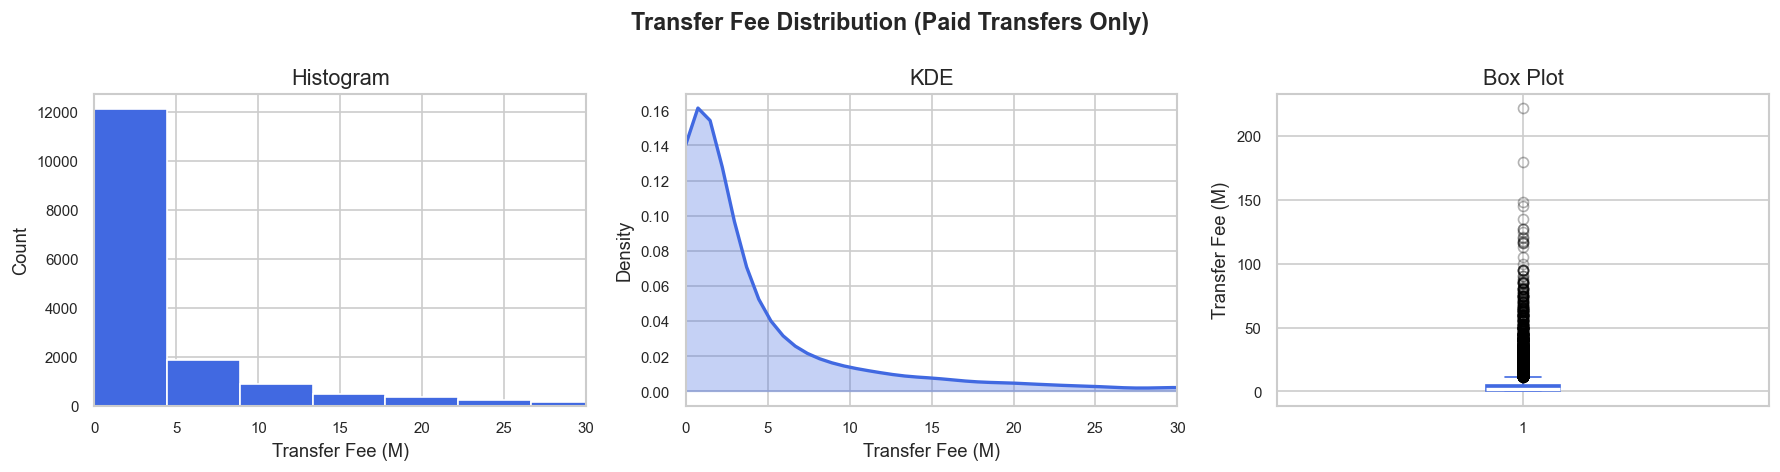

mean transfer fee: 4.97M
median transfer fee: 1.50M


In [18]:
# filtering free transfers and converting to millions
fees = transfers[transfers["transfer_fee"] > 0]["transfer_fee"].dropna() / 1_000_000

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Transfer Fee Distribution (Paid Transfers Only)", fontsize=14, fontweight="bold")

# histogram
axes[0].hist(fees, bins=50, color="royalblue", edgecolor="white")
axes[0].set_title("Histogram")
axes[0].set_xlabel("Transfer Fee (M)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 30)


# kde
kde = stats.gaussian_kde(fees)
x_range = np.linspace(fees.min(), fees.max(), 300)
axes[1].plot(x_range, kde(x_range), color="royalblue", linewidth=2)
axes[1].fill_between(x_range, kde(x_range), alpha=0.3, color="royalblue")
axes[1].set_title("KDE")
axes[1].set_xlabel("Transfer Fee (M)")
axes[1].set_ylabel("Density")
axes[1].set_xlim(0, 30)


# box plot
axes[2].boxplot(fees, patch_artist=True,
                boxprops=dict(facecolor="royalblue", color="royalblue"),
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(color="royalblue"),
                capprops=dict(color="royalblue"),
                flierprops=dict(marker="o", color="royalblue", alpha=0.3))
axes[2].set_title("Box Plot")
axes[2].set_ylabel("Transfer Fee (M)")

plt.tight_layout()
plt.show()

print(f"mean transfer fee: {fees.mean():.2f}M")
print(f"median transfer fee: {fees.median():.2f}M")

transfer fee distribution is right skewed as mean is highly above median, most of transfers are low, while a few deals is extremely high making the distribution asymmetric

# Transfer Fee vs Market Value

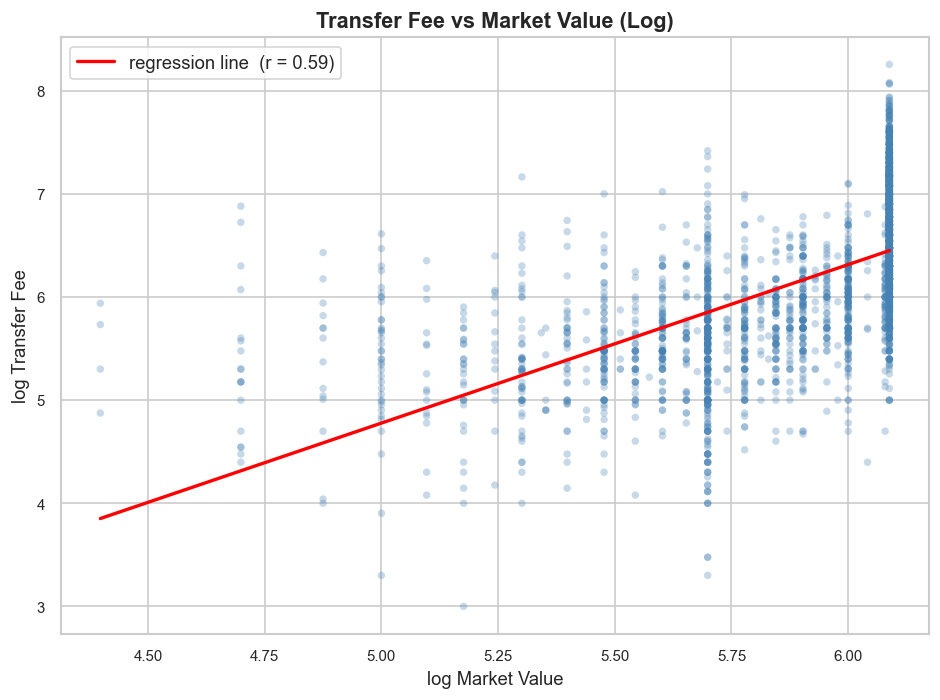

pearson r: 0.594


In [19]:
# correlation between transfer fee and market value
paid = transfers[
    (transfers["transfer_fee"] > 0) &
    (transfers["market_value_in_eur"] > 0)
][["transfer_fee", "market_value_in_eur"]].dropna()

sample = paid.sample(3000, random_state=42)

# log value for more readable plot
log_value = np.log10(sample["market_value_in_eur"])
log_fee   = np.log10(sample["transfer_fee"])

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(log_value, log_fee, alpha=0.3, color="steelblue", edgecolors="none", s=20)

m, b, r, p, _ = stats.linregress(log_value, log_fee)
x_line = np.linspace(log_value.min(), log_value.max(), 200)
ax.plot(x_line, m * x_line + b, color="red", linewidth=2, label=f"regression line  (r = {r:.2f})")

ax.set_title("Transfer Fee vs Market Value (Log)", fontweight="bold")
ax.set_xlabel("log Market Value")
ax.set_ylabel("log Transfer Fee")
ax.legend()

plt.tight_layout()
plt.show()

print(f"pearson r: {r:.3f}")

The scatter plot reveals positive correlation between market value and transfer fee

# Transfer Activity Over Seasons

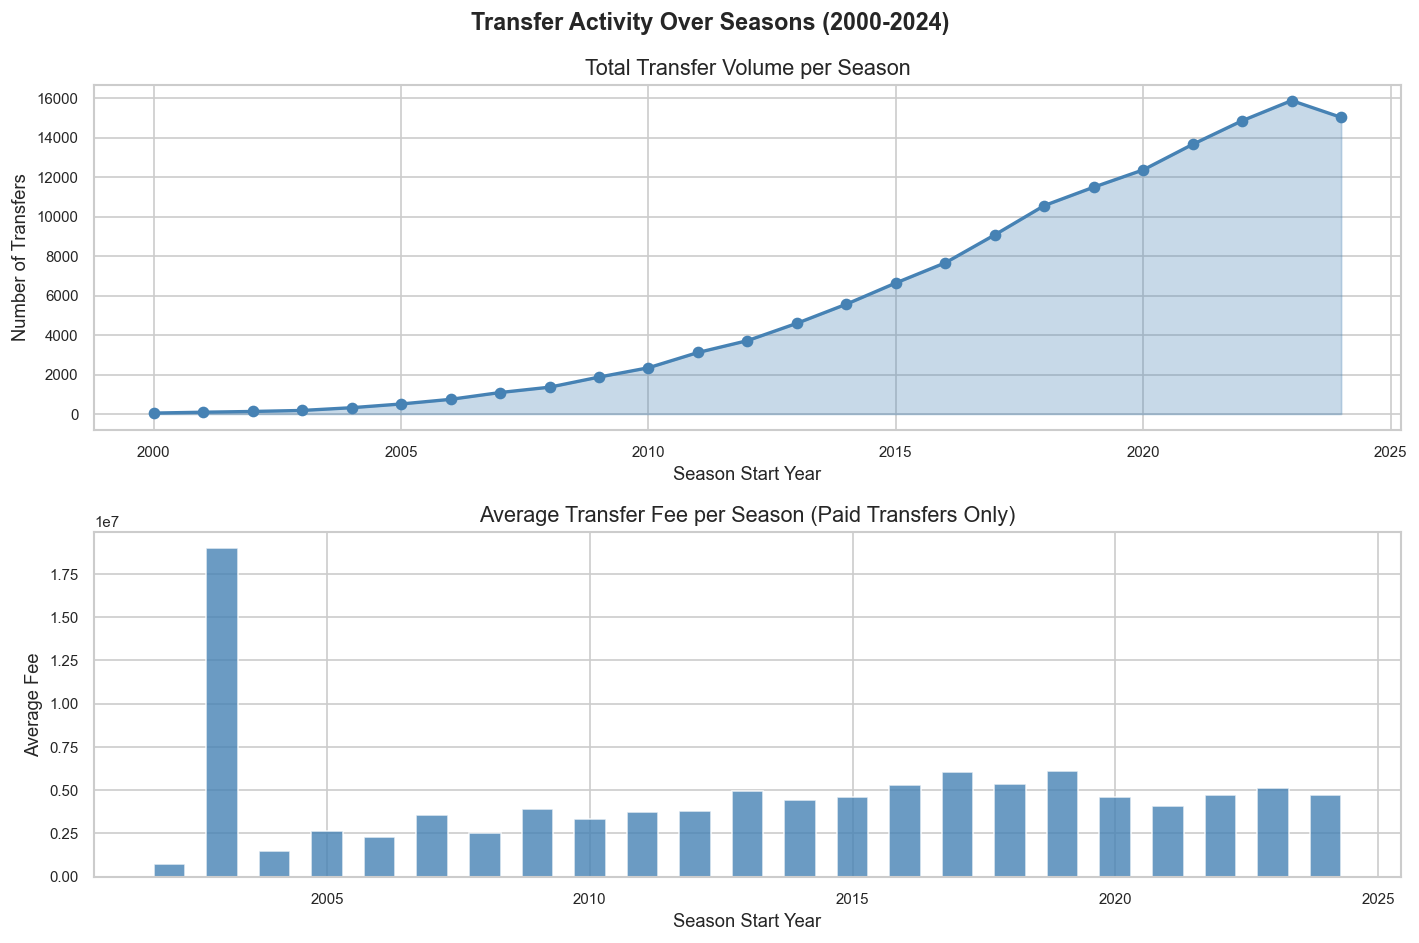

In [20]:
# transfer volume over seasons
transfers["season_start"] = transfers["transfer_season"].str[:2].apply(
    lambda x: 2000 + int(x) if x.isdigit() else None
)

# keep only 2000-2024 transfers
transfers_modern = transfers[
    (transfers["season_start"] >= 2000) &
    (transfers["season_start"] <= 2024)
]

season_counts = (
    transfers_modern.groupby("season_start")
    .size()
    .reset_index(name="transfer_count")
    .sort_values("season_start")
)

avg_fee = (
    transfers_modern[transfers_modern["transfer_fee"] > 0]
    .groupby("season_start")["transfer_fee"]
    .mean()
    .reset_index()
    .sort_values("season_start")
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("Transfer Activity Over Seasons (2000-2024)", fontsize=14, fontweight="bold")

# total volume
axes[0].fill_between(season_counts["season_start"], season_counts["transfer_count"], alpha=0.3, color="steelblue")
axes[0].plot(season_counts["season_start"], season_counts["transfer_count"], color="steelblue", linewidth=2, marker="o")
axes[0].set_title("Total Transfer Volume per Season")
axes[0].set_xlabel("Season Start Year")
axes[0].set_ylabel("Number of Transfers")

# average fee
axes[1].bar(avg_fee["season_start"], avg_fee["transfer_fee"], color="steelblue", alpha=0.8, width=0.6)
axes[1].set_title("Average Transfer Fee per Season (Paid Transfers Only)")
axes[1].set_xlabel("Season Start Year")
axes[1].set_ylabel("Average Fee")

plt.tight_layout()
plt.show()

# Transfer Fee by Player Position


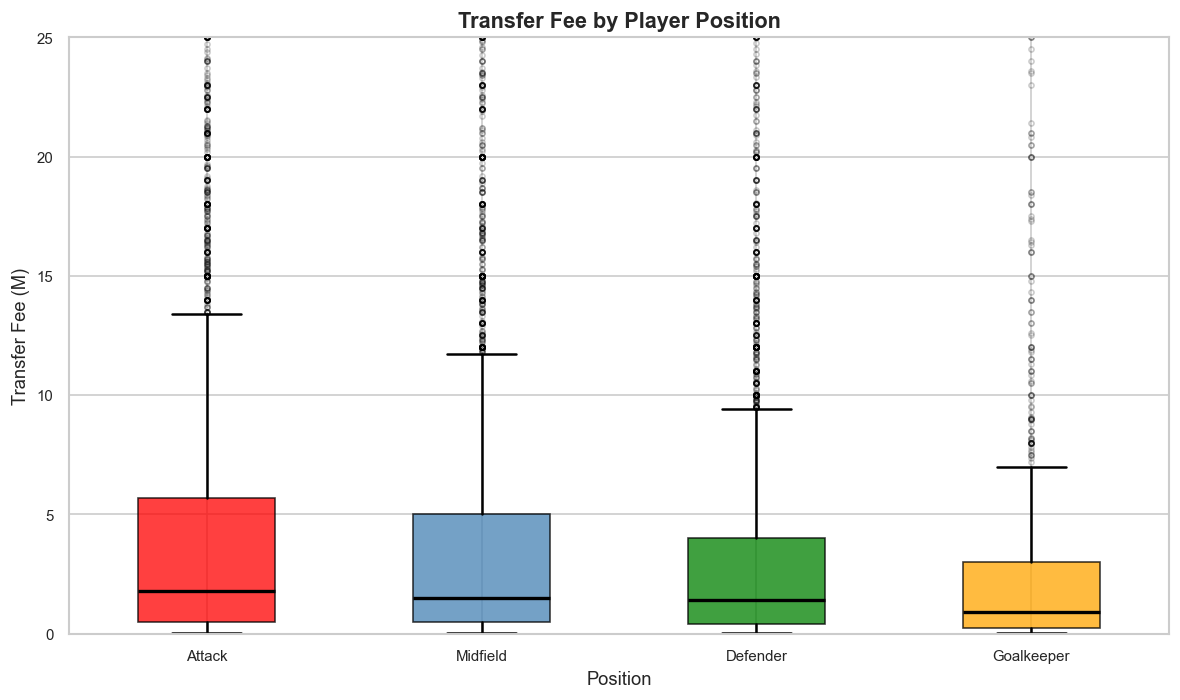

median transfer fee by position (M):
position
Attack        1.8
Midfield      1.5
Defender      1.4
Goalkeeper    0.9
Name: transfer_fee_m, dtype: float64


In [21]:

transfers_with_pos = transfers.merge(players[["player_id", "position"]], on="player_id", how="inner")

paid_pos = transfers_with_pos[
    (transfers_with_pos["transfer_fee"] > 0) &
    (transfers_with_pos["position"].isin(["Attack", "Midfield", "Defender", "Goalkeeper"]))
][["position", "transfer_fee"]].dropna().copy()

paid_pos["transfer_fee_m"] = paid_pos["transfer_fee"] / 1_000_000

position_order = (
    paid_pos.groupby("position")["transfer_fee_m"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

data_by_position = [
    paid_pos[paid_pos["position"] == pos]["transfer_fee_m"].values
    for pos in position_order
]

position_colors = ["red", "steelblue", "green", "orange"]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    data_by_position,
    labels=position_order,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", alpha=0.2, markersize=3)
)

for patch, color in zip(bp["boxes"], position_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for flier, color in zip(bp["fliers"], position_colors):
    flier.set_color(color)

# cut y axis at 25 to be more readable
ax.set_ylim(0, 25)

ax.set_title("Transfer Fee by Player Position", fontweight="bold")
ax.set_xlabel("Position")
ax.set_ylabel("Transfer Fee (M)")

plt.tight_layout()
plt.show()

print("median transfer fee by position (M):")
print(paid_pos.groupby("position")["transfer_fee_m"].median().sort_values(ascending=False))

the box plots reveal transfer cost of each position in the transfer market, attackers have the highest median fee as clubs prioritize goal-scoring, and goalkeepers are the cheapest as they have the lowest demand

# Financials and Performance Correlation Heatmap

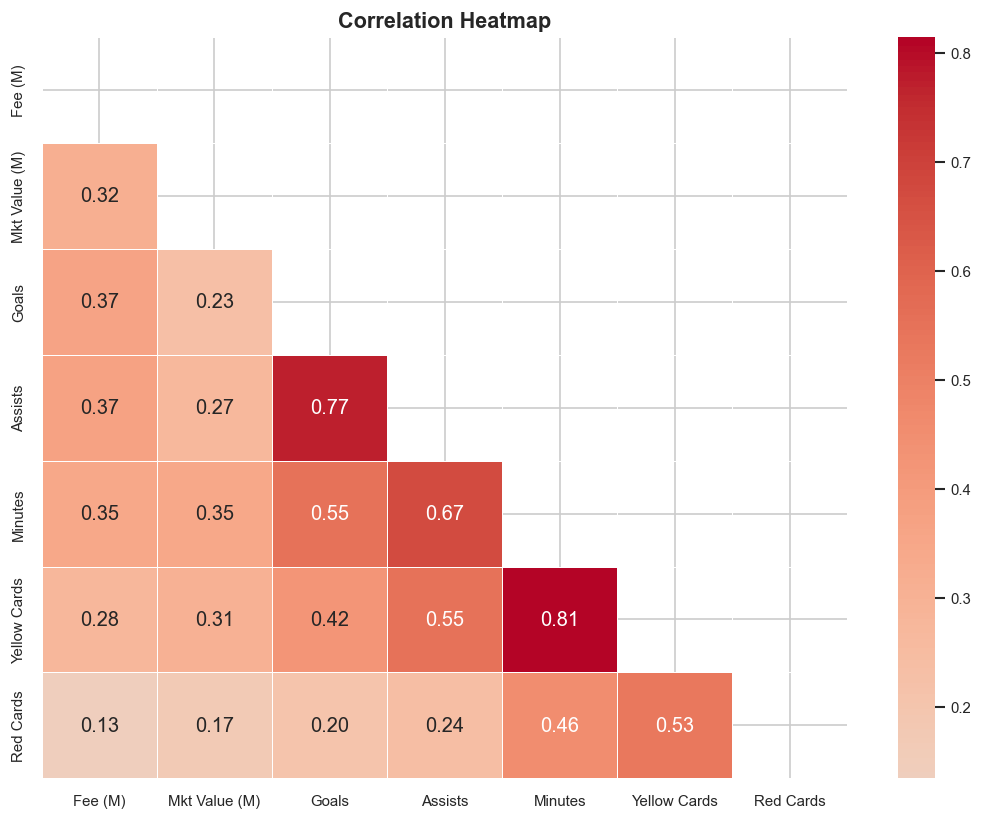

In [22]:
# aggregate appearances per player
player_stats = appearances.groupby("player_id").agg(
    goals=("goals", "sum"),
    assists=("assists", "sum"),
    minutes_played=("minutes_played", "sum"),
    yellow_cards=("yellow_cards", "sum"),
    red_cards=("red_cards", "sum")
).reset_index()

# financial information per player from transfers
player_financials = (
    transfers[transfers["transfer_fee"] > 0]
    .sort_values("transfer_date")
    .groupby("player_id")
    .last()
    .reset_index()
    [["player_id", "transfer_fee", "market_value_in_eur"]]
)

# convert to millions
player_financials["transfer_fee"] = player_financials["transfer_fee"] / 1_000_000
player_financials["market_value_in_eur"] = player_financials["market_value_in_eur"] / 1_000_000

combined = player_stats.merge(player_financials, on="player_id", how="inner")

heatmap_cols = ["transfer_fee", "market_value_in_eur", "goals", "assists", "minutes_played", "yellow_cards", "red_cards"]
corr = combined[heatmap_cols].corr()

# rename for cleaner labels
corr.columns = ["Fee (M)", "Mkt Value (M)", "Goals", "Assists", "Minutes", "Yellow Cards", "Red Cards"]
corr.index   = ["Fee (M)", "Mkt Value (M)", "Goals", "Assists", "Minutes", "Yellow Cards", "Red Cards"]

fig, ax = plt.subplots(figsize=(9, 7))

# mask the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Heatmap", fontweight="bold")

plt.tight_layout()
plt.show()

market value and goals have a positive correlation with transfer fees as they can reflect performance
Red cards has lower correlation with fees as it can indicate lower performance

# Dashboard Overview


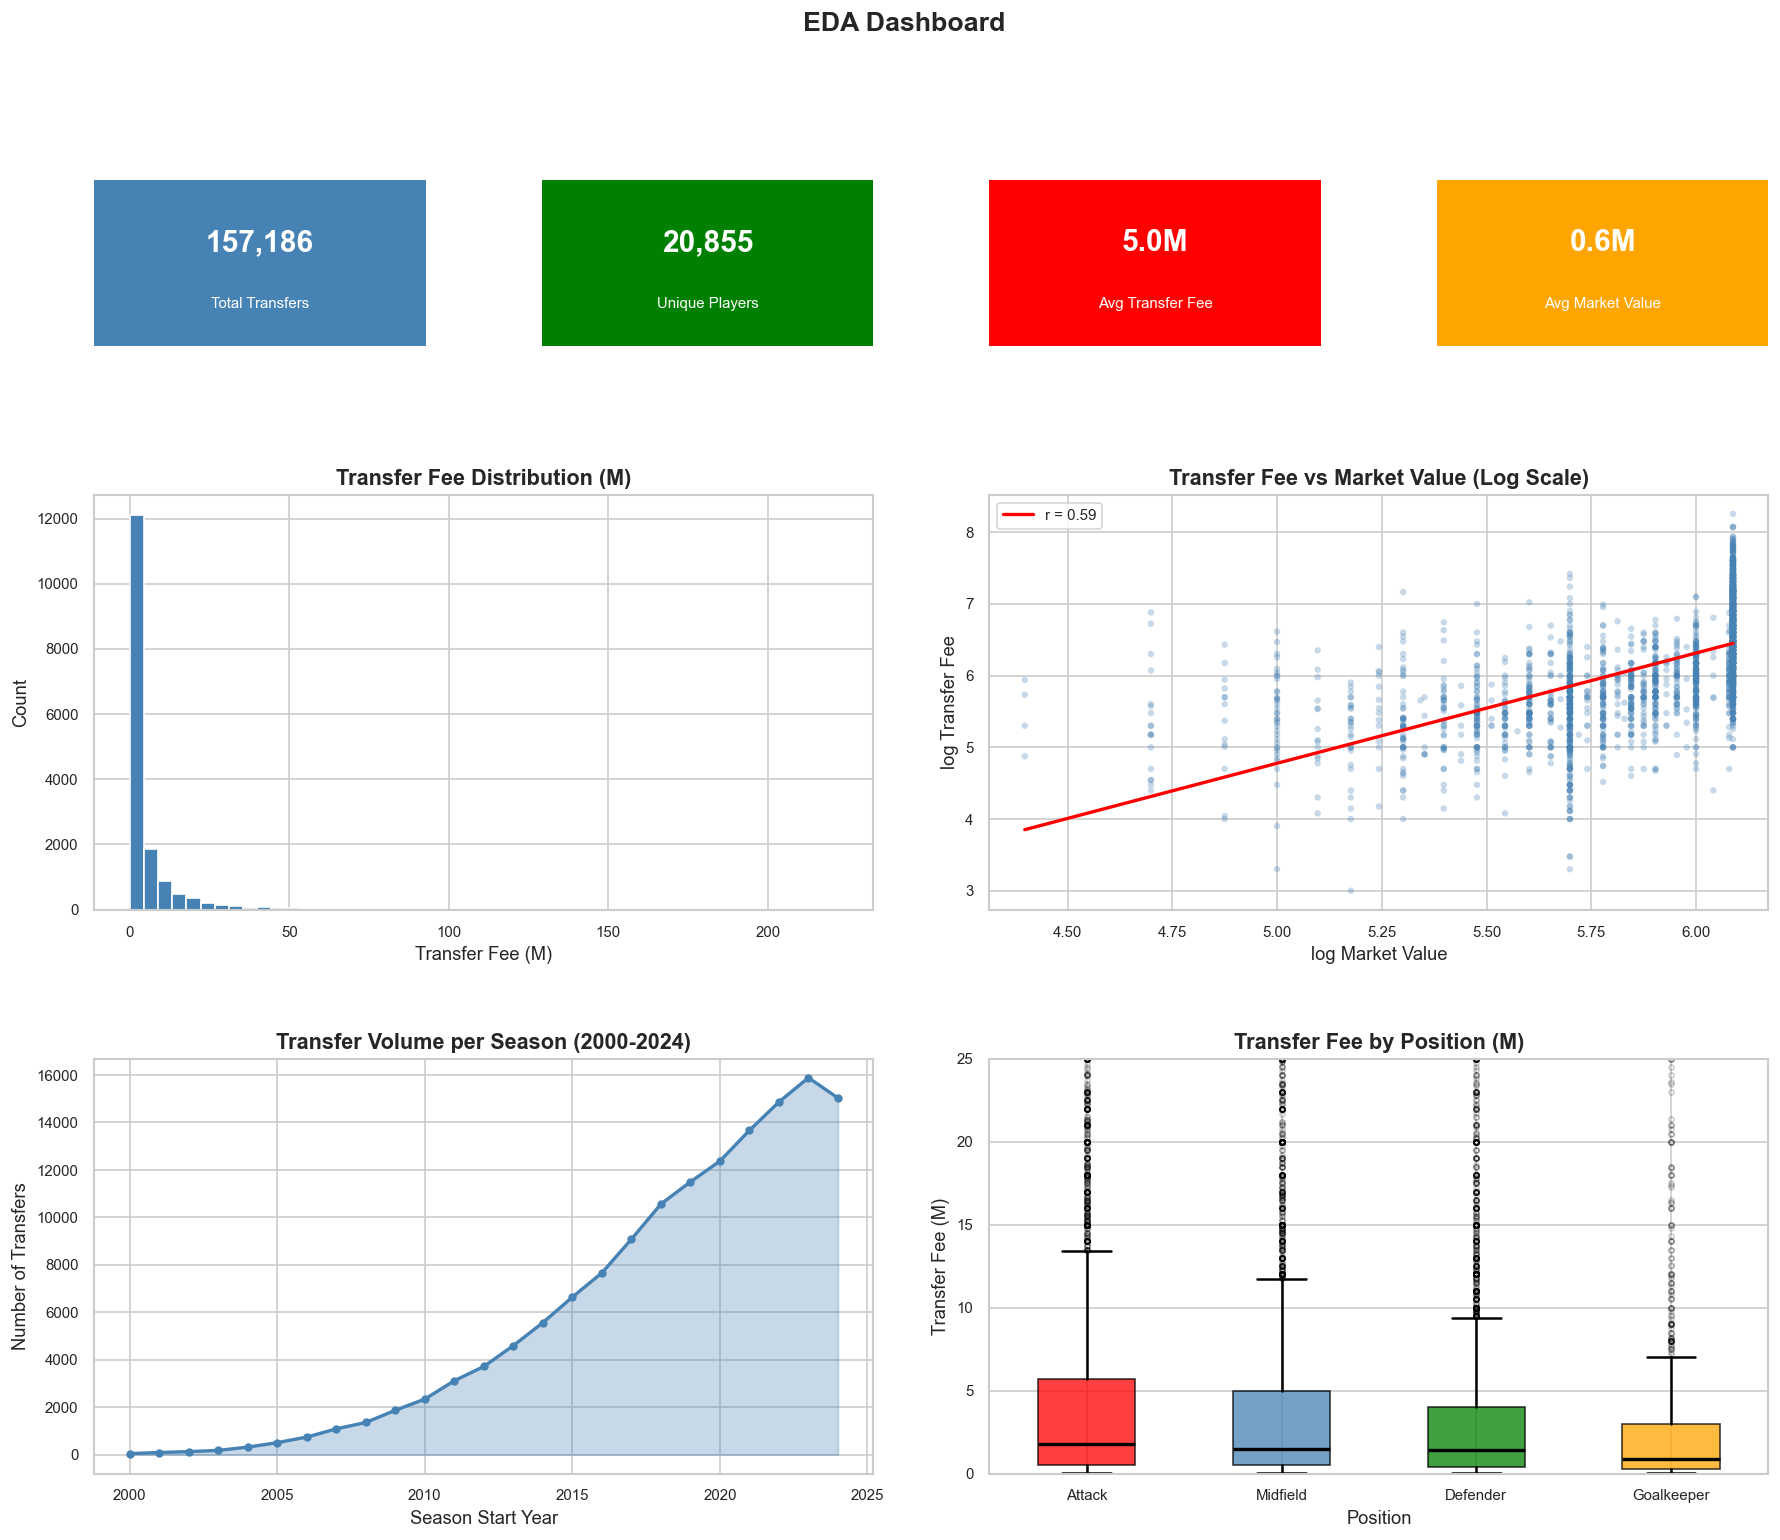

In [23]:

# kpis
total_transfers   = len(transfers)
paid_transfers    = transfers[transfers["transfer_fee"] > 0]
avg_fee           = paid_transfers["transfer_fee"].mean() / 1_000_000
avg_market_value  = transfers["market_value_in_eur"].mean() / 1_000_000
total_players     = transfers["player_id"].nunique()

fees = transfers[transfers["transfer_fee"] > 0]["transfer_fee"].dropna()

paid = transfers[
    (transfers["transfer_fee"] > 0) &
    (transfers["market_value_in_eur"] > 0)
][["transfer_fee", "market_value_in_eur"]].dropna()
sample = paid.sample(3000, random_state=42)
log_value = np.log10(sample["market_value_in_eur"])
log_fee   = np.log10(sample["transfer_fee"])

paid_pos_dash = transfers.merge(players[["player_id", "position"]], on="player_id", how="inner")
paid_pos_dash = paid_pos_dash[
    (paid_pos_dash["transfer_fee"] > 0) &
    (paid_pos_dash["position"].isin(["Attack", "Midfield", "Defender", "Goalkeeper"]))
][["position", "transfer_fee"]].dropna().copy()
paid_pos_dash["transfer_fee_m"] = paid_pos_dash["transfer_fee"] / 1_000_000
position_order_dash = (
    paid_pos_dash.groupby("position")["transfer_fee_m"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# figure and gridspec layout
fig = plt.figure(figsize=(18, 14))
fig.suptitle("EDA Dashboard", fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(
    3, 4,
    figure=fig,
    hspace=0.45,
    wspace=0.35,
    height_ratios=[0.8, 2, 2]
)

# kpi boxes
kpis = [
    ("Total Transfers", f"{total_transfers:,}","steelblue"),
    ("Unique Players", f"{total_players:,}",  "green"),
    ("Avg Transfer Fee", f"{avg_fee:.1f}M", "red"),
    ("Avg Market Value", f"{avg_market_value:.1f}M", "orange"),
]

for col, (label, value, color) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, col])
    ax_kpi.set_facecolor(color)
    ax_kpi.text(0.5, 0.62, value, ha="center", va="center",
                fontsize=18, fontweight="bold", color="white",
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.25, label, ha="center", va="center",
                fontsize=9, color="white",
                transform=ax_kpi.transAxes)
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_visible(False)

# transfer fee histogram
ax1 = fig.add_subplot(gs[1, :2])
ax1.hist(fees / 1_000_000, bins=50, color="steelblue", edgecolor="white")
ax1.set_title("Transfer Fee Distribution (M)", fontweight="bold")
ax1.set_xlabel("Transfer Fee (M)")
ax1.set_ylabel("Count")

# fee vs market value scatter
ax2 = fig.add_subplot(gs[1, 2:])
ax2.scatter(log_value, log_fee, alpha=0.3, color="steelblue", edgecolors="none", s=15)
m, b, r, p, _ = stats.linregress(log_value, log_fee)
x_line = np.linspace(log_value.min(), log_value.max(), 200)
ax2.plot(x_line, m * x_line + b, color="red", linewidth=2, label=f"r = {r:.2f}")
ax2.set_title("Transfer Fee vs Market Value (Log Scale)", fontweight="bold")
ax2.set_xlabel("log Market Value")
ax2.set_ylabel("log Transfer Fee")
ax2.legend(fontsize=9)

# transfer volume over seasons
ax3 = fig.add_subplot(gs[2, :2])
ax3.fill_between(season_counts["season_start"], season_counts["transfer_count"], alpha=0.3, color="steelblue")
ax3.plot(season_counts["season_start"], season_counts["transfer_count"], color="steelblue", linewidth=2, marker="o", markersize=4)
ax3.set_title("Transfer Volume per Season (2000-2024)", fontweight="bold")
ax3.set_xlabel("Season Start Year")
ax3.set_ylabel("Number of Transfers")

# fee by position box plots
ax4 = fig.add_subplot(gs[2, 2:])
data_by_pos_dash = [
    paid_pos_dash[paid_pos_dash["position"] == pos]["transfer_fee_m"].values
    for pos in position_order_dash
]
bp2 = ax4.boxplot(
    data_by_pos_dash,
    labels=position_order_dash,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", alpha=0.2, markersize=3)
)

for patch, color in zip(bp2["boxes"], position_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for flier, color in zip(bp2["fliers"], position_colors):
    flier.set_color(color)

ax4.set_ylim(0, 25)
ax4.set_title("Transfer Fee by Position (M)", fontweight="bold")
ax4.set_xlabel("Position")
ax4.set_ylabel("Transfer Fee (M)")

plt.show()